# NFL Data Processing — Build Lookup Tables for RL Environment

Reads `plays.csv` and `defensive_formations.csv`, produces `lookup_table.json` with:
1. **Play outcomes** — raw yardsGained arrays per situation bucket
2. **Turnover rates** — interception/fumble probability per bucket
3. **Defense distributions** — defensive formation frequencies per situation

In [1]:
# Cell 1: Load & Merge Data
import pandas as pd
import json
import random

plays = pd.read_csv('data/plays.csv')
def_formations = pd.read_csv('data/defensive_formations.csv')

print(f"Plays: {len(plays)}, Defensive formations: {len(def_formations)}")

# Merge on gameId + playId
df = plays.merge(def_formations[['gameId', 'playId', 'defFormation']], on=['gameId', 'playId'], how='inner')
print(f"After merge: {len(df)} plays ({len(plays) - len(df)} dropped — no defensive formation match)")

# Drop plays with no offense formation
before = len(df)
df = df.dropna(subset=['offenseFormation'])
print(f"Dropped NaN offenseFormation: {before - len(df)} plays")

# Derive playType: run, pass, play_action
df['playType'] = 'run'
df.loc[df['isDropback'] == True, 'playType'] = 'pass'
df.loc[(df['isDropback'] == True) & (df['playAction'] == True), 'playType'] = 'play_action'

print(f"\nPlay type distribution:\n{df['playType'].value_counts()}")

# Drop JUMBO and WILDCAT formations
before = len(df)
df = df[~df['offenseFormation'].isin(['JUMBO', 'WILDCAT'])].copy()
print(f"\nDropped JUMBO/WILDCAT: {before - len(df)} plays removed, {len(df)} remaining")

print(f"\nOffense formations:\n{df['offenseFormation'].value_counts()}")
print(f"\nDefensive formations:\n{df['defFormation'].value_counts()}")

Plays: 16124, Defensive formations: 16062
After merge: 16062 plays (62 dropped — no defensive formation match)
Dropped NaN offenseFormation: 188 plays

Play type distribution:
playType
pass           7236
run            6170
play_action    2468
Name: count, dtype: int64

Dropped JUMBO/WILDCAT: 162 plays removed, 15712 remaining

Offense formations:
offenseFormation
SHOTGUN       8783
SINGLEBACK    3914
EMPTY         1341
I_FORM        1033
PISTOL         641
Name: count, dtype: int64

Defensive formations:
defFormation
Nickel (4-2-5)    3541
Nickel (3-3-5)    3483
Nickel (2-4-5)    3392
3-4               1956
4-3               1374
Dime (2-3-6)       728
Dime (3-2-6)       489
Dime (4-1-6)       325
5-2                265
Quarter             81
5-3 Heavy           39
6-2 Goal Line       21
4-4                 18
Name: count, dtype: int64


In [2]:
# Cell 2: Analyze Bucket Sizes
buckets = df.groupby(['offenseFormation', 'playType', 'defFormation']).size().reset_index(name='count')
print(f"Total unique buckets: {len(buckets)}")
print(f"\nBucket size distribution:")
print(buckets['count'].describe())

# Show buckets with fewer than 10 plays
small_buckets = buckets[buckets['count'] < 10].sort_values('count')
print(f"\nBuckets with <10 plays: {len(small_buckets)}")
if len(small_buckets) > 0:
    print(small_buckets.to_string(index=False))

# Identify rare defensive formations to merge
rare_defs = buckets.groupby('defFormation')['count'].sum().sort_values()
print(f"\nTotal plays by defensive formation:")
print(rare_defs.to_string())

# Merge rare defenses into "Other" if they contribute to small buckets
rare_def_names = ['5-3 Heavy', '6-2 Goal Line', '4-4', 'Quarter']
rare_count = df[df['defFormation'].isin(rare_def_names)].shape[0]
print(f"\nRare defenses ({rare_def_names}): {rare_count} total plays")
print("→ Merging these into 'Other' to reduce sparse buckets")

df['defFormation'] = df['defFormation'].replace({name: 'Other' for name in rare_def_names})

# Re-check bucket sizes after merging
buckets2 = df.groupby(['offenseFormation', 'playType', 'defFormation']).size().reset_index(name='count')
small2 = buckets2[buckets2['count'] < 5]
print(f"\nAfter merging rare defenses:")
print(f"  Total buckets: {len(buckets2)}")
print(f"  Buckets with <5 plays: {len(small2)}")
if len(small2) > 0:
    print(small2.to_string(index=False))
print(f"\nDefensive formations now: {df['defFormation'].nunique()}")
print(df['defFormation'].value_counts())

Total unique buckets: 143

Bucket size distribution:
count     143.000000
mean      109.874126
std       230.596070
min         1.000000
25%         3.500000
50%        18.000000
75%        91.500000
max      1568.000000
Name: count, dtype: float64

Buckets with <10 plays: 58
offenseFormation    playType   defFormation  count
          I_FORM play_action   Dime (3-2-6)      1
         SHOTGUN play_action      5-3 Heavy      1
         SHOTGUN        pass      5-3 Heavy      1
      SINGLEBACK        pass            4-4      1
          PISTOL play_action   Dime (3-2-6)      1
      SINGLEBACK        pass  6-2 Goal Line      1
          PISTOL        pass   Dime (4-1-6)      1
          PISTOL        pass   Dime (3-2-6)      1
      SINGLEBACK        pass   Dime (3-2-6)      1
      SINGLEBACK        pass   Dime (4-1-6)      1
          I_FORM play_action   Dime (2-3-6)      1
          I_FORM play_action  6-2 Goal Line      1
      SINGLEBACK play_action            4-4      1
         

In [3]:
# Cell 3: Build Lookup Table
lookup = {}

for (formation, play_type, def_formation), group in df.groupby(['offenseFormation', 'playType', 'defFormation']):
    key = f"{formation}|{play_type}|{def_formation}"
    lookup[key] = {
        "yards": group['yardsGained'].tolist(),
        "results": group['passResult'].fillna('none').tolist(),  # 'none' for runs
    }

print(f"Total buckets: {len(lookup)}")
sizes = [len(v['yards']) for v in lookup.values()]
print(f"Bucket sizes — min: {min(sizes)}, max: {max(sizes)}, median: {sorted(sizes)[len(sizes)//2]}")
print(f"Total plays in lookup: {sum(sizes)}")

Total buckets: 127
Bucket sizes — min: 1, max: 1568, median: 27
Total plays in lookup: 15712


In [4]:
# Cell 4: Build Reward Mapping
# Reward logic:
#   passResult == "IN" (interception) → -5
#   passResult == "S" (sack) → -3
#   passResult == "I" (incomplete) → 0
#   Run or complete pass → yardsGained (raw value)

def compute_reward(yards, result):
    if result == 'IN':
        return -5
    elif result == 'S':
        return -3
    elif result == 'I':
        return 0
    else:
        return yards

for key, data in lookup.items():
    rewards = [compute_reward(y, r) for y, r in zip(data['yards'], data['results'])]
    data['rewards'] = rewards

# Verify reward mapping
print("Reward mapping examples:")
for result_type in ['C', 'I', 'S', 'IN', 'R', 'none']:
    for key, data in lookup.items():
        for i, r in enumerate(data['results']):
            if r == result_type:
                print(f"  {result_type}: yards={data['yards'][i]}, reward={data['rewards'][i]}")
                break
        else:
            continue
        break

# Summary stats
all_rewards = [r for data in lookup.values() for r in data['rewards']]
print(f"\nReward distribution:")
print(f"  Mean: {sum(all_rewards)/len(all_rewards):.2f}")
print(f"  Min: {min(all_rewards)}, Max: {max(all_rewards)}")
print(f"  Negative: {sum(1 for r in all_rewards if r < 0)}")
print(f"  Zero: {sum(1 for r in all_rewards if r == 0)}")
print(f"  Positive: {sum(1 for r in all_rewards if r > 0)}")

Reward mapping examples:
  C: yards=14, reward=14
  I: yards=0, reward=0
  S: yards=-5, reward=-3
  IN: yards=0, reward=-5
  R: yards=1, reward=1
  none: yards=3, reward=3

Reward distribution:
  Mean: 5.67
  Min: -61, Max: 98
  Negative: 1591
  Zero: 3462
  Positive: 10659


In [5]:
# Cell 5: Build Defense Distribution
defense_counts = df['defFormation'].value_counts()
defense_distribution = (defense_counts / defense_counts.sum()).to_dict()

print("Defensive formation distribution (for weighted sampling later):")
for name, prob in sorted(defense_distribution.items(), key=lambda x: -x[1]):
    print(f"  {name}: {prob:.3f} ({defense_counts[name]} plays)")

Defensive formation distribution (for weighted sampling later):
  Nickel (4-2-5): 0.225 (3541 plays)
  Nickel (3-3-5): 0.222 (3483 plays)
  Nickel (2-4-5): 0.216 (3392 plays)
  3-4: 0.124 (1956 plays)
  4-3: 0.087 (1374 plays)
  Dime (2-3-6): 0.046 (728 plays)
  Dime (3-2-6): 0.031 (489 plays)
  Dime (4-1-6): 0.021 (325 plays)
  5-2: 0.017 (265 plays)
  Other: 0.010 (159 plays)


In [6]:
# Cell 6: Save & Validate
import os

output = {
    "lookup": lookup,
    "defense_distribution": defense_distribution,
}

with open('data/lookup_table.json', 'w') as f:
    json.dump(output, f)

file_size = os.path.getsize('data/lookup_table.json') / 1024
print(f"Saved data/lookup_table.json ({file_size:.0f} KB)")

# Validate: sample from 5 random buckets
print("\n--- Validation: 10 random samples from 5 random buckets ---")
random.seed(42)
sample_keys = random.sample(list(lookup.keys()), 5)
for key in sample_keys:
    samples = random.choices(lookup[key]['rewards'], k=10)
    print(f"  {key}: {samples}")

# Action space summary
print("\n--- Action Space Summary ---")
action_combos = df.groupby(['offenseFormation', 'playType']).size().reset_index(name='count')
action_combos = action_combos.sort_values('count', ascending=False)
print(action_combos.to_string(index=False))
print(f"\nTotal (formation, playType) combos: {len(action_combos)}")

# Final stats
print(f"\n--- Final Stats ---")
print(f"Total plays in lookup: {sum(len(v['yards']) for v in lookup.values())}")
print(f"Total buckets: {len(lookup)}")
print(f"Offensive formations: {df['offenseFormation'].nunique()} — {sorted(df['offenseFormation'].dropna().unique())}")
print(f"Play types: {sorted(df['playType'].dropna().unique())}")
print(f"Defensive formations: {df['defFormation'].nunique()} — {sorted(df['defFormation'].dropna().unique())}")

Saved data/lookup_table.json (205 KB)

--- Validation: 10 random samples from 5 random buckets ---
  SHOTGUN|play_action|Dime (3-2-6): [0, 2, 11, 3, 14, 6, 20, 11, 0, 6]
  EMPTY|run|Dime (2-3-6): [16, 16, 16, 8, 8, 8, 16, 16, 8, 8]
  EMPTY|pass|Dime (2-3-6): [4, -3, 5, 5, 0, -3, -3, 9, 0, -3]
  SHOTGUN|run|Nickel (3-3-5): [1, 13, 5, -5, -1, 0, 13, 0, 3, -1]
  I_FORM|play_action|Other: [-3, -3, -3, -3, 2, 2, -3, 0, 2, 1]

--- Action Space Summary ---
offenseFormation    playType  count
         SHOTGUN        pass   5567
      SINGLEBACK         run   2608
         SHOTGUN         run   2233
           EMPTY        pass   1292
      SINGLEBACK play_action   1080
         SHOTGUN play_action    983
          I_FORM         run    734
          PISTOL         run    415
          I_FORM play_action    250
      SINGLEBACK        pass    226
          PISTOL play_action    131
          PISTOL        pass     95
          I_FORM        pass     49
           EMPTY         run     46
      

# Gradient Boosting Predictive Models for Play Outcomes

Train two models to replace/supplement the lookup table:
1. **Outcome Classifier** (multi-class): normal / touchdown / interception / fumble_lost
2. **Yards Regressor**: predicts `yardsGained` (continuous)

Uses 15 features from game state, play call, and defensive setup. Models use sklearn's `HistGradientBoosting` (similar to XGBoost).

In [7]:
# Cell 7: Load & Merge All Data Sources
import pandas as pd
import numpy as np
import json
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Reload plays fresh (with all columns)
plays_raw = pd.read_csv('data/plays.csv')
def_formations = pd.read_csv('data/defensive_formations.csv')
designed_pass = pd.read_csv('data/designed_pass.csv')
player_play = pd.read_csv('data/player_play.csv')

print(f"plays: {len(plays_raw)}, def_formations: {len(def_formations)}, designed_pass: {len(designed_pass)}, player_play: {len(player_play)}")

# --- Aggregate player_play to play level ---
# passRushers: count of initial pass rushers per play
pass_rushers = player_play.groupby(['gameId', 'playId'])['wasInitialPassRusher'].sum().reset_index()
pass_rushers.columns = ['gameId', 'playId', 'passRushers']

# fumble_lost: whether any player on the play lost a fumble
fumble_agg = player_play.groupby(['gameId', 'playId'])['fumbleLost'].max().reset_index()
fumble_agg.columns = ['gameId', 'playId', 'fumbleLost_flag']

print(f"Pass rusher aggregations: {len(pass_rushers)}")
print(f"Fumble aggregations: {len(fumble_agg)}")

# --- Merge everything onto plays ---
xdf = plays_raw.copy()

# Merge defensive formations
xdf = xdf.merge(def_formations[['gameId', 'playId', 'defFormation']], on=['gameId', 'playId'], how='inner')
print(f"After def_formations merge: {len(xdf)}")

# Merge designed pass (only need designedPass column)
dp_cols = ['gameId', 'playId', 'designedPass']
xdf = xdf.merge(designed_pass[dp_cols], on=['gameId', 'playId'], how='left')
print(f"After designed_pass merge: {len(xdf)}")

# Merge pass rushers
xdf = xdf.merge(pass_rushers, on=['gameId', 'playId'], how='left')
xdf['passRushers'] = xdf['passRushers'].fillna(0).astype(int)

# Merge fumble lost
xdf = xdf.merge(fumble_agg, on=['gameId', 'playId'], how='left')
xdf['fumbleLost_flag'] = xdf['fumbleLost_flag'].fillna(0).astype(int)

print(f"Final merged dataset: {len(xdf)} plays")
print(f"Columns: {len(xdf.columns)}")

plays: 16124, def_formations: 16062, designed_pass: 16124, player_play: 354727
Pass rusher aggregations: 16124
Fumble aggregations: 16124
After def_formations merge: 16062
After designed_pass merge: 16062
Final merged dataset: 16062 plays
Columns: 54


In [8]:
# Cell 8: Derive Features & Target Variables

# --- Derive playType ---
xdf['playType'] = 'run'
xdf.loc[xdf['isDropback'] == True, 'playType'] = 'pass'
xdf.loc[(xdf['isDropback'] == True) & (xdf['playAction'] == True), 'playType'] = 'play_action'

# --- Drop JUMBO/WILDCAT formations ---
before = len(xdf)
xdf = xdf[~xdf['offenseFormation'].isin(['JUMBO', 'WILDCAT'])].copy()
print(f"Dropped JUMBO/WILDCAT: {before - len(xdf)} plays removed, {len(xdf)} remaining")

# --- Merge rare defensive formations into 'Other' ---
rare_def_names = ['5-3 Heavy', '6-2 Goal Line', '4-4', 'Quarter']
xdf['defFormation'] = xdf['defFormation'].replace({name: 'Other' for name in rare_def_names})

# --- gameClock_seconds: parse MM:SS → total seconds ---
def parse_clock(val):
    if pd.isna(val):
        return 0
    parts = str(val).split(':')
    if len(parts) == 2:
        return int(parts[0]) * 60 + int(parts[1])
    return 0

xdf['gameClock_seconds'] = xdf['gameClock'].apply(parse_clock)

# --- Additional derived features ---
xdf['score_diff'] = xdf['preSnapHomeScore'] - xdf['preSnapVisitorScore']
xdf['is_third_down_long'] = ((xdf['down'] == 3) & (xdf['yardsToGo'] >= 7)).astype(int)
xdf['red_zone'] = (xdf['absoluteYardlineNumber'] >= 80).astype(int)

print(f"\nDerived feature stats:")
print(f"  score_diff: mean={xdf['score_diff'].mean():.1f}, std={xdf['score_diff'].std():.1f}")
print(f"  is_third_down_long: {xdf['is_third_down_long'].mean():.3f} ({xdf['is_third_down_long'].sum()} plays)")
print(f"  red_zone: {xdf['red_zone'].mean():.3f} ({xdf['red_zone'].sum()} plays)")

# --- 6-class outcome target variable ---
# Priority order: interception > fumble > sack > incompletion > touchdown > completion
xdf['is_touchdown'] = xdf['playDescription'].str.contains('TOUCHDOWN', case=False, na=False).astype(int)

xdf['outcome'] = 'completion'  # default for runs and completed passes
xdf.loc[xdf['passResult'] == 'I', 'outcome'] = 'incompletion'
xdf.loc[xdf['passResult'] == 'S', 'outcome'] = 'sack'
xdf.loc[xdf['passResult'] == 'IN', 'outcome'] = 'interception'
xdf.loc[xdf['fumbleLost_flag'] > 0, 'outcome'] = 'fumble_lost'
xdf.loc[xdf['is_touchdown'] == 1, 'outcome'] = 'touchdown'

print(f"\nOutcome distribution (6 classes):")
print(xdf['outcome'].value_counts())
print(f"\nOutcome rates:")
for oc in xdf['outcome'].value_counts().index:
    print(f"  {oc}: {xdf['outcome'].value_counts()[oc] / len(xdf) * 100:.1f}%")

# --- Handle missing/NaN values ---
xdf['pff_passCoverage'] = xdf['pff_passCoverage'].fillna('none')
xdf['pff_manZone'] = xdf['pff_manZone'].fillna('none')
xdf['designedPass'] = xdf['designedPass'].fillna('none')
xdf.loc[xdf['playType'] == 'run', 'passRushers'] = 0
xdf['pff_runConceptPrimary'] = xdf['pff_runConceptPrimary'].fillna('none')
xdf['receiverAlignment'] = xdf['receiverAlignment'].fillna('unknown')

# Drop rows with missing critical values
before = len(xdf)
xdf = xdf.dropna(subset=['down', 'yardsToGo', 'absoluteYardlineNumber', 'yardsGained']).copy()
print(f"\nDropped rows with missing critical values: {before - len(xdf)}")

print(f"\nFinal dataset: {len(xdf)} plays")

Dropped JUMBO/WILDCAT: 162 plays removed, 15900 remaining

Derived feature stats:
  score_diff: mean=1.2, std=9.3
  is_third_down_long: 0.095 (1506 plays)
  red_zone: 0.265 (4217 plays)

Outcome distribution (6 classes):
outcome
completion      11572
incompletion     2897
touchdown         588
sack              567
interception      174
fumble_lost       102
Name: count, dtype: int64

Outcome rates:
  completion: 72.8%
  incompletion: 18.2%
  touchdown: 3.7%
  sack: 3.6%
  interception: 1.1%
  fumble_lost: 0.6%

Dropped rows with missing critical values: 0

Final dataset: 15900 plays


In [9]:
# Cell 9: Encode Categoricals & Train/Val/Test Split
from sklearn.preprocessing import OrdinalEncoder

# Define feature columns
CATEGORICAL_FEATURES = [
    'offenseFormation', 'receiverAlignment', 'playType',
    'pff_runConceptPrimary', 'defFormation', 'pff_passCoverage',
    'pff_manZone', 'designedPass'
]
NUMERIC_FEATURES = [
    'quarter', 'down', 'yardsToGo', 'gameClock_seconds',
    'absoluteYardlineNumber', 'isDropback', 'passRushers',
    'score_diff', 'is_third_down_long', 'red_zone'
]

# OrdinalEncoder on categoricals (handles unknown values better than LabelEncoder)
ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
cat_encoded = ord_enc.fit_transform(xdf[CATEGORICAL_FEATURES].astype(str))

# Store encoded columns back
for i, col in enumerate(CATEGORICAL_FEATURES):
    xdf[col + '_enc'] = cat_encoded[:, i]

# Print categories for reference
label_encoders = {}  # keep dict for saving to JSON
for i, col in enumerate(CATEGORICAL_FEATURES):
    cats = list(ord_enc.categories_[i])
    label_encoders[col] = cats
    print(f"{col}: {len(cats)} classes — {cats}")

# Build feature matrix
feature_cols = NUMERIC_FEATURES + [c + '_enc' for c in CATEGORICAL_FEATURES]
print(f"\nTotal features: {len(feature_cols)}")
print(f"Feature columns: {feature_cols}")

# Build categorical_features index list for HistGradientBoosting
cat_indices = list(range(len(NUMERIC_FEATURES), len(feature_cols)))
print(f"Categorical feature indices: {cat_indices}")

# Encode outcome target
outcome_le = LabelEncoder()
xdf['outcome_enc'] = outcome_le.fit_transform(xdf['outcome'])
print(f"\nOutcome classes: {list(outcome_le.classes_)}")
outcome_mapping = {i: c for i, c in enumerate(outcome_le.classes_)}
print(f"Outcome mapping: {outcome_mapping}")

# --- Train/Val/Test Split by Game ---
game_ids = xdf['gameId'].unique()
np.random.seed(42)
np.random.shuffle(game_ids)

n_train = int(len(game_ids) * 0.70)
n_val = int(len(game_ids) * 0.15)

train_games = set(game_ids[:n_train])
val_games = set(game_ids[n_train:n_train + n_val])
test_games = set(game_ids[n_train + n_val:])

train_mask = xdf['gameId'].isin(train_games)
val_mask = xdf['gameId'].isin(val_games)
test_mask = xdf['gameId'].isin(test_games)

X_train = xdf.loc[train_mask, feature_cols].values
X_val = xdf.loc[val_mask, feature_cols].values
X_test = xdf.loc[test_mask, feature_cols].values

y_train_outcome = xdf.loc[train_mask, 'outcome_enc'].values
y_val_outcome = xdf.loc[val_mask, 'outcome_enc'].values
y_test_outcome = xdf.loc[test_mask, 'outcome_enc'].values

y_train_yards = xdf.loc[train_mask, 'yardsGained'].values
y_val_yards = xdf.loc[val_mask, 'yardsGained'].values
y_test_yards = xdf.loc[test_mask, 'yardsGained'].values

# Keep outcome labels for per-outcome regressor training
y_train_outcome_labels = xdf.loc[train_mask, 'outcome'].values
y_test_outcome_labels = xdf.loc[test_mask, 'outcome'].values

print(f"\n--- Split by Game ---")
print(f"Train: {len(X_train)} plays ({len(train_games)} games)")
print(f"Val:   {len(X_val)} plays ({len(val_games)} games)")
print(f"Test:  {len(X_test)} plays ({len(test_games)} games)")

print(f"\nTrain outcome distribution:")
for cls_idx, cls_name in outcome_mapping.items():
    count = (y_train_outcome == cls_idx).sum()
    print(f"  {cls_name}: {count} ({count/len(y_train_outcome)*100:.1f}%)")

offenseFormation: 6 classes — ['EMPTY', 'I_FORM', 'PISTOL', 'SHOTGUN', 'SINGLEBACK', nan]
receiverAlignment: 11 classes — ['1x0', '1x1', '2x0', '2x1', '2x2', '3x0', '3x1', '3x2', '3x3', '4x1', 'unknown']
playType: 3 classes — ['pass', 'play_action', 'run']
pff_runConceptPrimary: 13 classes — ['COUNTER', 'DRAW', 'FB RUN', 'INSIDE ZONE', 'MAN', 'OUTSIDE ZONE', 'POWER', 'PULL LEAD', 'SNEAK', 'TRAP', 'TRICK', 'UNDEFINED', 'none']
defFormation: 10 classes — ['3-4', '4-3', '5-2', 'Dime (2-3-6)', 'Dime (3-2-6)', 'Dime (4-1-6)', 'Nickel (2-4-5)', 'Nickel (3-3-5)', 'Nickel (4-2-5)', 'Other']
pff_passCoverage: 19 classes — ['2-Man', 'Bracket', 'Cover 6-Left', 'Cover-0', 'Cover-1', 'Cover-1 Double', 'Cover-2', 'Cover-3', 'Cover-3 Cloud Left', 'Cover-3 Cloud Right', 'Cover-3 Double Cloud', 'Cover-3 Seam', 'Cover-6 Right', 'Goal Line', 'Miscellaneous', 'Prevent', 'Quarters', 'Red Zone', 'none']
pff_manZone: 4 classes — ['Man', 'Other', 'Zone', 'none']
designedPass: 13 classes — ['deep_left', 'deep_

## Data Visualizations

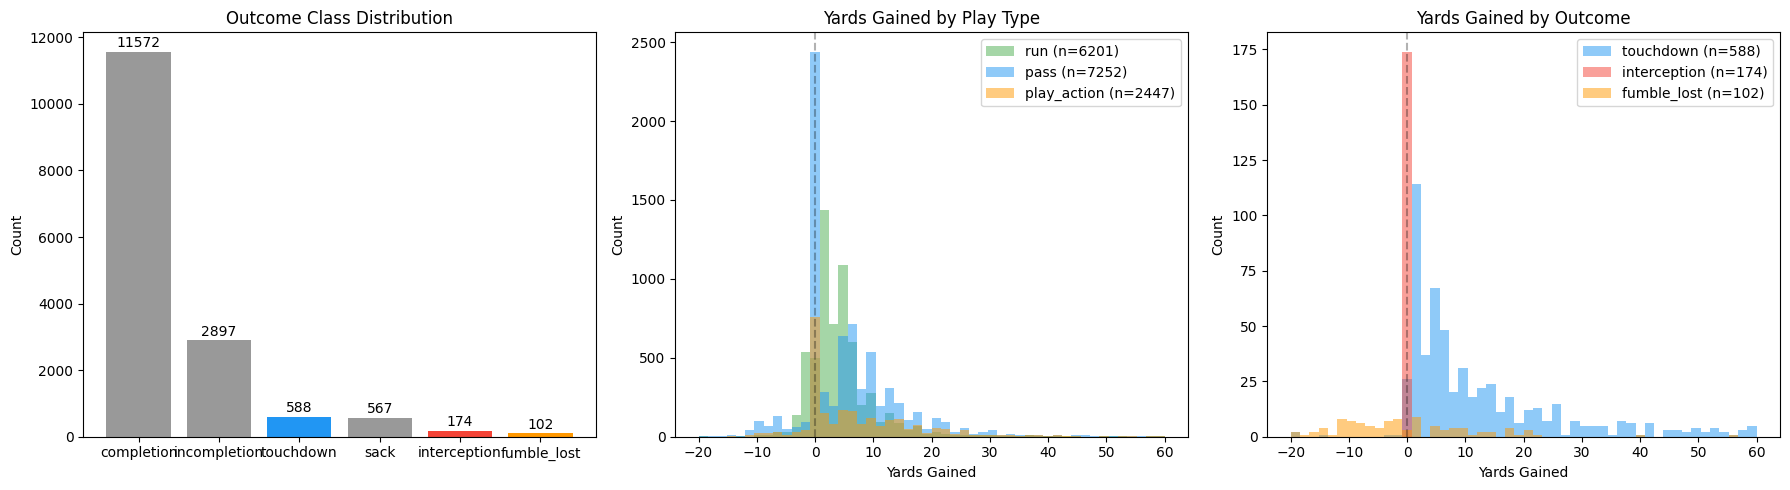


Yards gained stats:
count    15900.000000
mean         5.489748
std          8.863769
min        -68.000000
25%          0.000000
50%          3.000000
75%          8.000000
max         98.000000
Name: yardsGained, dtype: float64


In [10]:
# Cell 10: Outcome Class Balance & Yards Distribution
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Outcome class balance
outcome_counts = xdf['outcome'].value_counts()
colors = {'normal': '#4CAF50', 'touchdown': '#2196F3', 'interception': '#F44336', 'fumble_lost': '#FF9800'}
bars = axes[0].bar(outcome_counts.index, outcome_counts.values,
                   color=[colors.get(x, '#999') for x in outcome_counts.index])
axes[0].set_title('Outcome Class Distribution')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, outcome_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 str(val), ha='center', va='bottom', fontsize=10)

# 2. Yards distribution by play type
for pt, color in [('run', '#4CAF50'), ('pass', '#2196F3'), ('play_action', '#FF9800')]:
    subset = xdf[xdf['playType'] == pt]['yardsGained']
    axes[1].hist(subset, bins=50, alpha=0.5, label=f'{pt} (n={len(subset)})', color=color, range=(-20, 60))
axes[1].set_title('Yards Gained by Play Type')
axes[1].set_xlabel('Yards Gained')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].axvline(x=0, color='black', linestyle='--', alpha=0.3)

# 3. Yards distribution by outcome
for oc, color in colors.items():
    subset = xdf[xdf['outcome'] == oc]['yardsGained']
    if len(subset) > 0:
        axes[2].hist(subset, bins=50, alpha=0.5, label=f'{oc} (n={len(subset)})', color=color, range=(-20, 60))
axes[2].set_title('Yards Gained by Outcome')
axes[2].set_xlabel('Yards Gained')
axes[2].set_ylabel('Count')
axes[2].legend()
axes[2].axvline(x=0, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nYards gained stats:")
print(xdf['yardsGained'].describe())

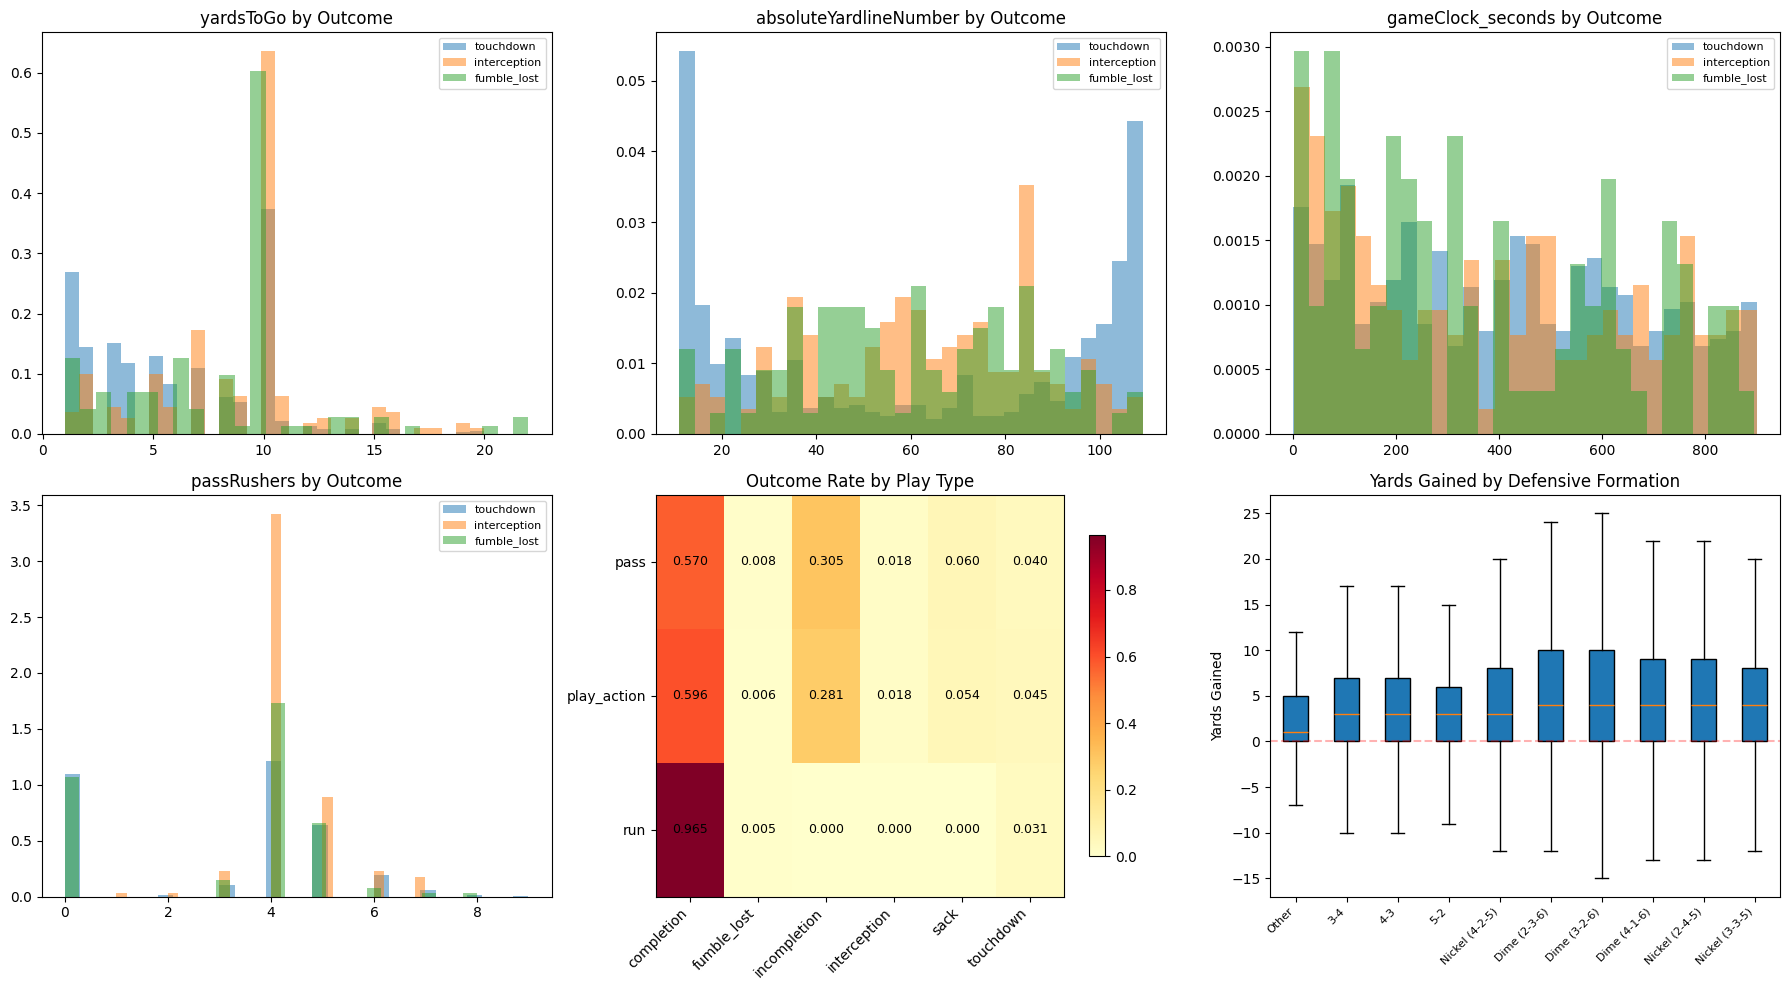

In [11]:
# Cell 11: Feature Distributions, Correlation Heatmap, Play Type × Outcome

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Numeric feature histograms by outcome
numeric_to_plot = ['yardsToGo', 'absoluteYardlineNumber', 'gameClock_seconds', 'passRushers']
for i, feat in enumerate(numeric_to_plot[:4]):
    ax = axes[i // 3, i % 3]
    for oc in ['normal', 'touchdown', 'interception', 'fumble_lost']:
        subset = xdf[xdf['outcome'] == oc][feat]
        if len(subset) > 0:
            ax.hist(subset, bins=30, alpha=0.5, label=oc, density=True)
    ax.set_title(f'{feat} by Outcome')
    ax.legend(fontsize=8)

# 5. Play type × outcome crosstab heatmap
ax = axes[1, 1]
ct = pd.crosstab(xdf['playType'], xdf['outcome'], normalize='index')
im = ax.imshow(ct.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(ct.columns)))
ax.set_xticklabels(ct.columns, rotation=45, ha='right')
ax.set_yticks(range(len(ct.index)))
ax.set_yticklabels(ct.index)
ax.set_title('Outcome Rate by Play Type')
for i in range(len(ct.index)):
    for j in range(len(ct.columns)):
        ax.text(j, i, f'{ct.values[i,j]:.3f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, shrink=0.8)

# 6. Defensive formation impact — box plots
ax = axes[1, 2]
def_order = xdf.groupby('defFormation')['yardsGained'].median().sort_values().index
box_data = [xdf[xdf['defFormation'] == d]['yardsGained'].values for d in def_order]
bp = ax.boxplot(box_data, labels=def_order, vert=True, patch_artist=True, showfliers=False)
ax.set_xticklabels(def_order, rotation=45, ha='right', fontsize=8)
ax.set_title('Yards Gained by Defensive Formation')
ax.set_ylabel('Yards Gained')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Train HistGradientBoosting Models

In [12]:
# Cell 12: Train Outcome Classifier (calibrated — no balanced weighting)
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, mean_absolute_error, r2_score

# Train on natural class frequencies for calibrated probabilities
# No sample_weight='balanced' — we want P(outcome) to match real NFL rates
clf = HistGradientBoostingClassifier(
    max_iter=500,
    max_depth=6,
    learning_rate=0.1,
    min_samples_leaf=5,
    categorical_features=cat_indices,
    random_state=42,
    early_stopping=True,
    n_iter_no_change=20,
    validation_fraction=0.15,
    verbose=1,
)

clf.fit(X_train, y_train_outcome)

print(f"\nIterations used: {clf.n_iter_}")

# Test set predictions
y_pred_outcome = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)

print(f"\n=== Test Set Classification Report ===")
print(classification_report(y_test_outcome, y_pred_outcome,
                            target_names=[outcome_mapping[i] for i in range(len(outcome_mapping))]))

Binning 0.001 GB of training data: 

0.027 s
Binning 0.000 GB of validation data: 

0.001 s
Fitting gradient boosted rounds:


Fit 228 trees in 1.209 s, (7023 total leaves)
Time spent computing histograms: 0.377s
Time spent finding best splits:  0.239s
Time spent applying splits:      0.384s
Time spent predicting:           0.011s

Iterations used: 38

=== Test Set Classification Report ===
              precision    recall  f1-score   support

  completion       0.79      0.95      0.86      1761
 fumble_lost       0.00      0.00      0.00        15
incompletion       0.40      0.20      0.27       416
interception       0.00      0.00      0.00        29
        sack       0.37      0.07      0.12       101
   touchdown       0.38      0.16      0.23        81

    accuracy                           0.74      2403
   macro avg       0.32      0.23      0.25      2403
weighted avg       0.67      0.74      0.69      2403



In [13]:
# Cell 13: Train Per-Outcome Quantile Regressors (two-stage sampling)
# Only completion and touchdown need quantile regressors.
# incompletion → always 0 yards
# sack → empirical (always negative)
# interception → always 0 yards
# fumble_lost → empirical (small sample)

QUANTILE_LEVELS = [0.1, 0.25, 0.5, 0.75, 0.9]
QUANTILE_OUTCOMES = ['completion', 'touchdown']  # train quantile models for these
EMPIRICAL_OUTCOMES = ['sack', 'fumble_lost']      # sample from historical data
FIXED_OUTCOMES = ['incompletion', 'interception']  # always 0 yards

outcome_regressors = {}

for outcome_class in outcome_mapping.values():
    mask_train = y_train_outcome_labels == outcome_class
    n_samples = mask_train.sum()
    print(f"\n--- {outcome_class}: {n_samples} training samples ---")

    if outcome_class in FIXED_OUTCOMES:
        # Always 0 yards
        outcome_regressors[outcome_class] = {'type': 'fixed', 'yards': 0.0}
        print(f"  → Fixed: always 0 yards")

    elif outcome_class in EMPIRICAL_OUTCOMES:
        # Store empirical distribution for sampling
        yards_list = y_train_yards[mask_train].tolist()
        outcome_regressors[outcome_class] = {
            'type': 'empirical',
            'yards': yards_list,
            'mean': float(np.mean(yards_list)) if yards_list else 0,
            'std': float(np.std(yards_list)) if yards_list else 0,
        }
        print(f"  → Empirical distribution (n={len(yards_list)})")
        if yards_list:
            print(f"  → Mean: {np.mean(yards_list):.1f}, Std: {np.std(yards_list):.1f}, Range: [{min(yards_list)}, {max(yards_list)}]")

    elif outcome_class in QUANTILE_OUTCOMES:
        # Train quantile regressors
        quantile_models = {}
        for q in QUANTILE_LEVELS:
            qreg = HistGradientBoostingRegressor(
                loss='quantile',
                quantile=q,
                max_iter=500,
                max_depth=6,
                learning_rate=0.1,
                min_samples_leaf=5,
                categorical_features=cat_indices,
                random_state=42,
                early_stopping=True,
                n_iter_no_change=20,
                validation_fraction=0.15,
                verbose=0,
            )
            qreg.fit(X_train[mask_train], y_train_yards[mask_train])
            quantile_models[q] = qreg

        outcome_regressors[outcome_class] = {
            'type': 'quantile',
            'models': quantile_models,
            'quantile_levels': QUANTILE_LEVELS,
        }
        iters = [quantile_models[q].n_iter_ for q in QUANTILE_LEVELS]
        print(f"  → Trained 5 quantile regressors (iters: {iters})")

        # Eval quantile coverage on test set
        mask_test = y_test_outcome_labels == outcome_class
        if mask_test.sum() > 0:
            preds = {q: quantile_models[q].predict(X_test[mask_test]) for q in QUANTILE_LEVELS}
            actual = y_test_yards[mask_test]
            for q in QUANTILE_LEVELS:
                coverage = (actual <= preds[q]).mean()
                print(f"  → q={q:.2f}: coverage={coverage:.3f} (ideal={q:.2f}), median pred={np.median(preds[q]):.1f}")

print("\n=== Summary ===")
for oc, info in outcome_regressors.items():
    print(f"  {oc}: {info['type']}")


--- completion: 8114 training samples ---


  → Trained 5 quantile regressors (iters: [70, 54, 59, 80, 66])
  → q=0.10: coverage=0.127 (ideal=0.10), median pred=0.4
  → q=0.25: coverage=0.283 (ideal=0.25), median pred=2.0
  → q=0.50: coverage=0.526 (ideal=0.50), median pred=4.1
  → q=0.75: coverage=0.722 (ideal=0.75), median pred=7.7
  → q=0.90: coverage=0.878 (ideal=0.90), median pred=12.3

--- fumble_lost: 73 training samples ---
  → Empirical distribution (n=73)
  → Mean: -0.5, Std: 13.8, Range: [-39, 56]

--- incompletion: 2032 training samples ---
  → Fixed: always 0 yards

--- interception: 120 training samples ---
  → Fixed: always 0 yards

--- sack: 387 training samples ---
  → Empirical distribution (n=387)
  → Mean: -6.7, Std: 3.6, Range: [-18, 7]

--- touchdown: 431 training samples ---


  → Trained 5 quantile regressors (iters: [53, 60, 110, 78, 116])
  → q=0.10: coverage=0.222 (ideal=0.10), median pred=4.6
  → q=0.25: coverage=0.309 (ideal=0.25), median pred=8.1
  → q=0.50: coverage=0.556 (ideal=0.50), median pred=10.5
  → q=0.75: coverage=0.728 (ideal=0.75), median pred=11.0
  → q=0.90: coverage=0.778 (ideal=0.90), median pred=12.3

=== Summary ===
  completion: quantile
  fumble_lost: empirical
  incompletion: fixed
  interception: fixed
  sack: empirical
  touchdown: quantile


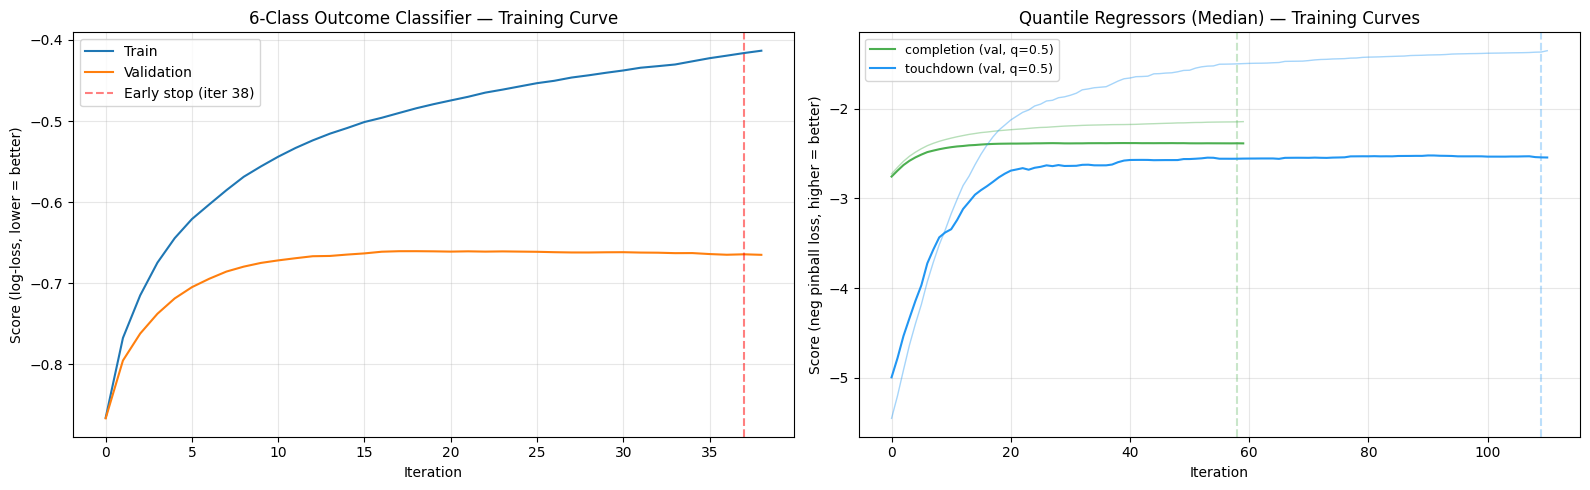

Classifier: train=-0.4133, val=-0.6649, stopped at iter 38
  completion q=0.1: train=-0.7609, val=-0.8690, iters=70
  completion q=0.25: train=-1.5228, val=-1.6595, iters=54
  completion q=0.5: train=-2.1439, val=-2.3860, iters=59
  completion q=0.75: train=-1.9787, val=-2.3505, iters=80
  completion q=0.9: train=-1.2396, val=-1.7073, iters=66
  touchdown q=0.1: train=-1.0131, val=-1.5294, iters=53
  touchdown q=0.25: train=-1.6807, val=-3.0908, iters=60
  touchdown q=0.5: train=-1.3537, val=-2.5433, iters=110
  touchdown q=0.75: train=-1.1263, val=-1.8301, iters=78
  touchdown q=0.9: train=-0.4761, val=-1.5647, iters=116


In [14]:
# Cell 13b: Training Curves — Train & Validation Score Over Iterations
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Classifier training curve
ax = axes[0]
ax.plot(clf.train_score_, label='Train', linewidth=1.5)
ax.plot(clf.validation_score_, label='Validation', linewidth=1.5)
ax.axvline(x=clf.n_iter_ - 1, color='red', linestyle='--', alpha=0.5, label=f'Early stop (iter {clf.n_iter_})')
ax.set_xlabel('Iteration')
ax.set_ylabel('Score (log-loss, lower = better)')
ax.set_title('6-Class Outcome Classifier — Training Curve')
ax.legend()
ax.grid(alpha=0.3)

# 2. Quantile regressor training curves (median q=0.5)
ax = axes[1]
colors = {'completion': '#4CAF50', 'touchdown': '#2196F3'}
for oc, info in outcome_regressors.items():
    if info['type'] == 'quantile':
        median_model = info['models'][0.5]
        ax.plot(median_model.train_score_, color=colors.get(oc, '#999'), linestyle='-', alpha=0.4, linewidth=1)
        ax.plot(median_model.validation_score_, color=colors.get(oc, '#999'), linestyle='-', linewidth=1.5, label=f'{oc} (val, q=0.5)')
        ax.axvline(x=median_model.n_iter_ - 1, color=colors.get(oc, '#999'), linestyle='--', alpha=0.3)
ax.set_xlabel('Iteration')
ax.set_ylabel('Score (neg pinball loss, higher = better)')
ax.set_title('Quantile Regressors (Median) — Training Curves')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Classifier: train={clf.train_score_[-1]:.4f}, val={clf.validation_score_[-1]:.4f}, stopped at iter {clf.n_iter_}")
for oc, info in outcome_regressors.items():
    if info['type'] == 'quantile':
        for q in QUANTILE_LEVELS:
            m = info['models'][q]
            print(f"  {oc} q={q}: train={m.train_score_[-1]:.4f}, val={m.validation_score_[-1]:.4f}, iters={m.n_iter_}")

## Model Evaluation & Visualization

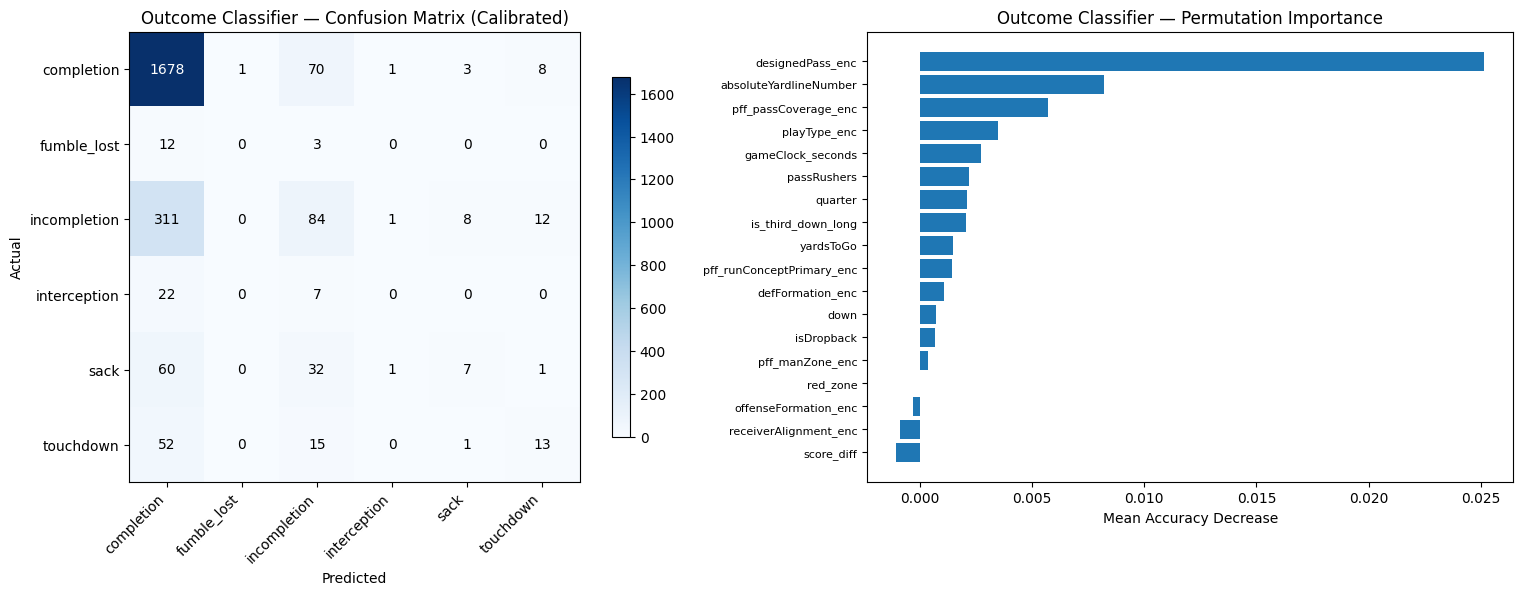

In [15]:
# Cell 14: Confusion Matrix & Feature Importance for Classifier
from sklearn.inspection import permutation_importance

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Confusion matrix
cm = confusion_matrix(y_test_outcome, y_pred_outcome)
class_names = [outcome_mapping[i] for i in range(len(outcome_mapping))]
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks(range(len(class_names)))
axes[0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0].set_yticks(range(len(class_names)))
axes[0].set_yticklabels(class_names)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Outcome Classifier — Confusion Matrix (Calibrated)')
for i in range(len(class_names)):
    for j in range(len(class_names)):
        axes[0].text(j, i, str(cm[i, j]), ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.colorbar(im, ax=axes[0], shrink=0.8)

# 2. Feature importance via permutation importance
perm_imp_clf = permutation_importance(clf, X_test, y_test_outcome, n_repeats=10, random_state=42)
importance = perm_imp_clf.importances_mean
sorted_idx = np.argsort(importance)
axes[1].barh(range(len(sorted_idx)), importance[sorted_idx])
axes[1].set_yticks(range(len(sorted_idx)))
axes[1].set_yticklabels([feature_cols[i] for i in sorted_idx], fontsize=8)
axes[1].set_title('Outcome Classifier — Permutation Importance')
axes[1].set_xlabel('Mean Accuracy Decrease')

plt.tight_layout()
plt.show()

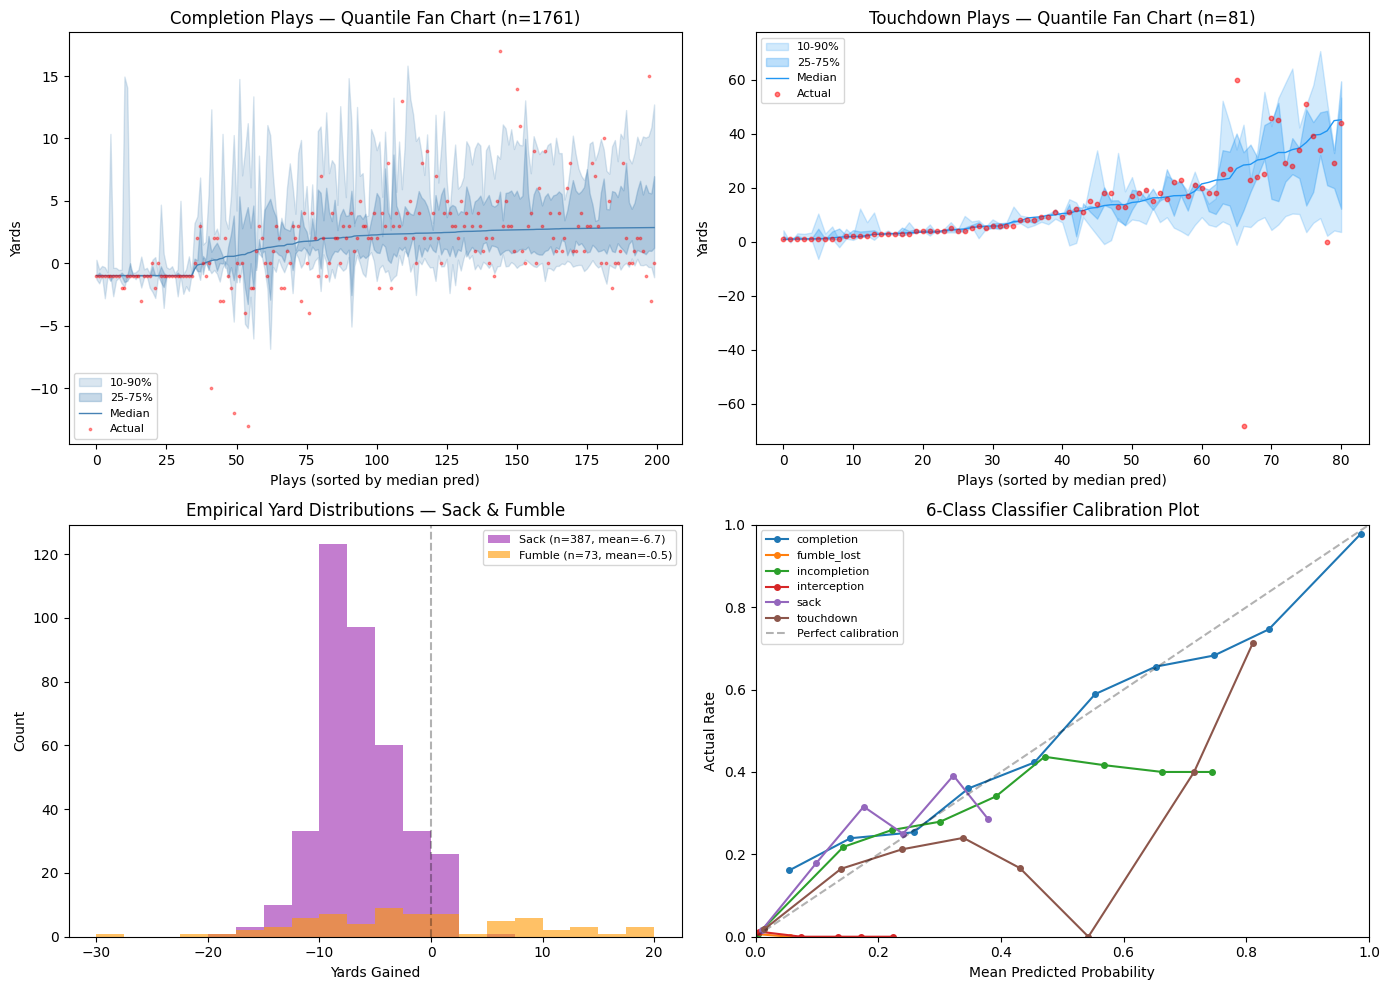

In [16]:
# Cell 15: Quantile Regressor Evaluation & Calibration Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Helper: sample from quantile predictions ---
def sample_from_quantiles(quantile_preds, quantile_levels):
    u = np.random.uniform()
    extended_q = [0.0] + list(quantile_levels) + [1.0]
    q10, q90 = quantile_preds[0], quantile_preds[-1]
    iqr = q90 - q10
    extended_v = [q10 - iqr * 0.5] + list(quantile_preds) + [q90 + iqr * 0.5]
    return np.interp(u, extended_q, extended_v)

# 1. Completion plays: quantile fan chart
ax = axes[0, 0]
mask_comp = y_test_outcome_labels == 'completion'
if mask_comp.sum() > 0 and outcome_regressors['completion']['type'] == 'quantile':
    models = outcome_regressors['completion']['models']
    q_preds = {q: models[q].predict(X_test[mask_comp]) for q in QUANTILE_LEVELS}
    actual = y_test_yards[mask_comp]
    sort_idx = np.argsort(q_preds[0.5])[:200]
    x = np.arange(len(sort_idx))
    ax.fill_between(x, q_preds[0.1][sort_idx], q_preds[0.9][sort_idx], alpha=0.2, color='steelblue', label='10-90%')
    ax.fill_between(x, q_preds[0.25][sort_idx], q_preds[0.75][sort_idx], alpha=0.3, color='steelblue', label='25-75%')
    ax.plot(x, q_preds[0.5][sort_idx], color='steelblue', linewidth=1, label='Median')
    ax.scatter(x, actual[sort_idx], s=3, alpha=0.4, color='red', label='Actual', zorder=5)
    ax.set_xlabel('Plays (sorted by median pred)')
    ax.set_ylabel('Yards')
    ax.set_title(f'Completion Plays — Quantile Fan Chart (n={mask_comp.sum()})')
    ax.legend(fontsize=8)

# 2. Touchdown plays: quantile fan chart
ax = axes[0, 1]
mask_td = y_test_outcome_labels == 'touchdown'
if mask_td.sum() > 0 and outcome_regressors['touchdown']['type'] == 'quantile':
    models = outcome_regressors['touchdown']['models']
    q_preds = {q: models[q].predict(X_test[mask_td]) for q in QUANTILE_LEVELS}
    actual = y_test_yards[mask_td]
    sort_idx = np.argsort(q_preds[0.5])
    x = np.arange(len(sort_idx))
    ax.fill_between(x, q_preds[0.1][sort_idx], q_preds[0.9][sort_idx], alpha=0.2, color='#2196F3', label='10-90%')
    ax.fill_between(x, q_preds[0.25][sort_idx], q_preds[0.75][sort_idx], alpha=0.3, color='#2196F3', label='25-75%')
    ax.plot(x, q_preds[0.5][sort_idx], color='#2196F3', linewidth=1, label='Median')
    ax.scatter(x, actual[sort_idx], s=10, alpha=0.5, color='red', label='Actual', zorder=5)
    ax.set_xlabel('Plays (sorted by median pred)')
    ax.set_ylabel('Yards')
    ax.set_title(f'Touchdown Plays — Quantile Fan Chart (n={mask_td.sum()})')
    ax.legend(fontsize=8)

# 3. Sack + fumble empirical distributions
ax = axes[1, 0]
for oc, color, label in [('sack', '#9C27B0', 'Sack'), ('fumble_lost', '#FF9800', 'Fumble')]:
    info = outcome_regressors[oc]
    if info['type'] == 'empirical':
        ax.hist(info['yards'], bins=20, alpha=0.6, color=color,
                label=f'{label} (n={len(info["yards"])}, mean={info["mean"]:.1f})', range=(-30, 20))
ax.set_title('Empirical Yard Distributions — Sack & Fumble')
ax.set_xlabel('Yards Gained')
ax.set_ylabel('Count')
ax.legend(fontsize=8)
ax.axvline(x=0, color='black', linestyle='--', alpha=0.3)

# 4. Calibration plot: predicted prob vs actual rate per outcome
ax = axes[1, 1]
n_bins = 10
for cls_idx, cls_name in outcome_mapping.items():
    probs = y_pred_proba[:, cls_idx]
    actual = (y_test_outcome == cls_idx).astype(float)
    bin_edges = np.linspace(0, probs.max() + 1e-8, n_bins + 1)
    bin_centers = []
    bin_rates = []
    for b in range(n_bins):
        mask_bin = (probs >= bin_edges[b]) & (probs < bin_edges[b + 1])
        if mask_bin.sum() >= 5:
            bin_centers.append(probs[mask_bin].mean())
            bin_rates.append(actual[mask_bin].mean())
    if bin_centers:
        ax.plot(bin_centers, bin_rates, 'o-', label=cls_name, markersize=4)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Actual Rate')
ax.set_title('6-Class Classifier Calibration Plot')
ax.legend(fontsize=8)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

In [17]:
# Cell 16: Per-Play-Type Performance & Calibration Check

# --- Two-stage prediction helper with 6-class outcomes ---
def sample_from_quantiles(quantile_preds, quantile_levels):
    u = np.random.uniform()
    extended_q = [0.0] + list(quantile_levels) + [1.0]
    q10, q90 = quantile_preds[0], quantile_preds[-1]
    iqr = q90 - q10
    extended_v = [q10 - iqr * 0.5] + list(quantile_preds) + [q90 + iqr * 0.5]
    return np.interp(u, extended_q, extended_v)

def two_stage_predict_yards(X, outcome_regressors, outcome_mapping, clf):
    proba = clf.predict_proba(X)
    pred_yards = np.zeros(len(X))
    pred_outcomes = []

    for i in range(len(X)):
        outcome_idx = np.random.choice(len(outcome_mapping), p=proba[i])
        outcome_name = outcome_mapping[outcome_idx]
        pred_outcomes.append(outcome_name)

        info = outcome_regressors[outcome_name]
        if info['type'] == 'quantile':
            q_vals = [info['models'][q].predict(X[i:i+1])[0] for q in info['quantile_levels']]
            pred_yards[i] = sample_from_quantiles(q_vals, info['quantile_levels'])
        elif info['type'] == 'empirical':
            pred_yards[i] = np.random.choice(info['yards'])
        elif info['type'] == 'fixed':
            pred_yards[i] = info['yards']

    return np.array(pred_outcomes), pred_yards

# --- Per-play-type metrics ---
test_df = xdf[test_mask].copy()
test_df['pred_outcome'] = y_pred_outcome
test_df['pred_outcome_label'] = test_df['pred_outcome'].map(outcome_mapping)

np.random.seed(42)
_, test_df_twostage_yards = two_stage_predict_yards(X_test, outcome_regressors, outcome_mapping, clf)
test_df['pred_yards_twostage'] = test_df_twostage_yards

print("=== Per-Play-Type Accuracy ===")
for pt in ['run', 'pass', 'play_action']:
    mask = test_df['playType'] == pt
    if mask.sum() == 0:
        continue
    acc = (test_df.loc[mask, 'outcome_enc'] == test_df.loc[mask, 'pred_outcome']).mean()
    rmse_pt = np.sqrt(mean_squared_error(test_df.loc[mask, 'yardsGained'], test_df.loc[mask, 'pred_yards_twostage']))
    mae_pt = mean_absolute_error(test_df.loc[mask, 'yardsGained'], test_df.loc[mask, 'pred_yards_twostage'])
    print(f"\n  {pt} ({mask.sum()} plays):")
    print(f"    Outcome accuracy: {acc:.3f}")
    print(f"    Two-stage yards RMSE: {rmse_pt:.2f}, MAE: {mae_pt:.2f}")

# --- Calibration check ---
print("\n=== Calibration Check: Predicted vs Actual Event Rates (6 classes) ===")
for cls_idx, cls_name in outcome_mapping.items():
    actual_rate = (y_test_outcome == cls_idx).mean()
    pred_mean_prob = y_pred_proba[:, cls_idx].mean()
    pred_rate = (y_pred_outcome == cls_idx).mean()
    print(f"  {cls_name}:")
    print(f"    Actual rate:       {actual_rate:.4f} ({(y_test_outcome == cls_idx).sum()} plays)")
    print(f"    Mean pred prob:    {pred_mean_prob:.4f}")
    print(f"    Predicted rate:    {pred_rate:.4f} ({(y_pred_outcome == cls_idx).sum()} plays)")

=== Per-Play-Type Accuracy ===

  run (989 plays):
    Outcome accuracy: 0.967
    Two-stage yards RMSE: 7.83, MAE: 5.08

  pass (1068 plays):
    Outcome accuracy: 0.590
    Two-stage yards RMSE: 11.86, MAE: 8.25

  play_action (346 plays):
    Outcome accuracy: 0.566
    Two-stage yards RMSE: 16.01, MAE: 11.41

=== Calibration Check: Predicted vs Actual Event Rates (6 classes) ===
  completion:
    Actual rate:       0.7328 (1761 plays)
    Mean pred prob:    0.7442
    Predicted rate:    0.8885 (2135 plays)
  fumble_lost:
    Actual rate:       0.0062 (15 plays)
    Mean pred prob:    0.0038
    Predicted rate:    0.0004 (1 plays)
  incompletion:
    Actual rate:       0.1731 (416 plays)
    Mean pred prob:    0.1783
    Predicted rate:    0.0878 (211 plays)
  interception:
    Actual rate:       0.0121 (29 plays)
    Mean pred prob:    0.0091
    Predicted rate:    0.0012 (3 plays)
  sack:
    Actual rate:       0.0420 (101 plays)
    Mean pred prob:    0.0292
    Predicted rate:  

## Save Models & Artifacts

In [18]:
# Cell 17: Save Models & Artifacts
import os
import joblib

# Clean up ALL old artifacts first
for old in os.listdir('data'):
    if old.startswith('yards_') and (old.endswith('.joblib') or old.endswith('.json')):
        os.remove(f'data/{old}')
        print(f"Removed old data/{old}")

# Save classifier
joblib.dump(clf, 'data/outcome_classifier.joblib')
print(f"\nSaved classifier: {os.path.getsize('data/outcome_classifier.joblib') / 1024:.0f} KB")

# Save per-outcome regressors
for oc, info in outcome_regressors.items():
    if info['type'] == 'quantile':
        for q in info['quantile_levels']:
            path = f'data/yards_q{q:.2f}_{oc}.joblib'
            joblib.dump(info['models'][q], path)
            print(f"Saved {path}: {os.path.getsize(path) / 1024:.0f} KB")
    elif info['type'] == 'empirical':
        path = f'data/yards_{oc}.json'
        with open(path, 'w') as f:
            json.dump({'yards': info['yards'], 'mean': info['mean'], 'std': info['std']}, f)
        print(f"Saved {path}: {os.path.getsize(path) / 1024:.1f} KB")
    elif info['type'] == 'fixed':
        print(f"  {oc}: fixed at {info['yards']} yards (no file needed)")

# Save label encoders
encoder_data = {}
for col, cats in label_encoders.items():
    encoder_data[col] = cats
encoder_data['outcome'] = list(outcome_le.classes_)

with open('data/label_encoders.json', 'w') as f:
    json.dump(encoder_data, f, indent=2)
print(f"Saved label encoders: {os.path.getsize('data/label_encoders.json') / 1024:.1f} KB")

# Save feature list
model_features = {
    'numeric_features': NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'feature_cols': feature_cols,
    'categorical_indices': cat_indices,
    'outcome_mapping': {str(k): v for k, v in outcome_mapping.items()},
    'quantile_levels': QUANTILE_LEVELS,
    'outcome_regressor_types': {oc: info['type'] for oc, info in outcome_regressors.items()},
}

with open('data/model_features.json', 'w') as f:
    json.dump(model_features, f, indent=2)
print(f"Saved feature list: {os.path.getsize('data/model_features.json') / 1024:.1f} KB")

print("\n--- All artifacts saved ---")

Removed old data/yards_q0.10_normal.joblib
Removed old data/yards_q0.90_normal.joblib
Removed old data/yards_q0.75_fumble_lost.joblib
Removed old data/yards_q0.50_interception.joblib
Removed old data/yards_q0.25_fumble_lost.joblib
Removed old data/yards_q0.90_touchdown.joblib
Removed old data/yards_q0.90_fumble_lost.joblib
Removed old data/yards_q0.10_interception.joblib
Removed old data/yards_q0.50_fumble_lost.joblib
Removed old data/yards_q0.50_normal.joblib
Removed old data/yards_q0.10_fumble_lost.joblib
Removed old data/yards_q0.75_interception.joblib
Removed old data/yards_q0.25_interception.joblib
Removed old data/yards_q0.25_normal.joblib
Removed old data/yards_q0.75_normal.joblib
Removed old data/yards_q0.50_touchdown.joblib
Removed old data/yards_q0.75_touchdown.joblib
Removed old data/yards_q0.10_touchdown.joblib
Removed old data/yards_q0.25_touchdown.joblib
Removed old data/yards_q0.90_interception.joblib

Saved classifier: 961 KB
Saved data/yards_q0.10_completion.joblib: 28

In [19]:
# Cell 18: Two-Stage 6-Class Inference Test
import joblib
import json
import numpy as np
import random

# Load models fresh
test_clf = joblib.load('data/outcome_classifier.joblib')

with open('data/model_features.json') as f:
    feat_data = json.load(f)

with open('data/label_encoders.json') as f:
    enc_data = json.load(f)

# Load per-outcome regressors
test_regressors = {}
q_levels = feat_data['quantile_levels']
for oc, reg_type in feat_data['outcome_regressor_types'].items():
    if reg_type == 'quantile':
        models = {}
        for q in q_levels:
            models[q] = joblib.load(f'data/yards_q{q:.2f}_{oc}.joblib')
        test_regressors[oc] = {'type': 'quantile', 'models': models, 'quantile_levels': q_levels}
    elif reg_type == 'empirical':
        with open(f'data/yards_{oc}.json') as f:
            emp = json.load(f)
        test_regressors[oc] = {'type': 'empirical', 'yards': emp['yards']}
    elif reg_type == 'fixed':
        test_regressors[oc] = {'type': 'fixed', 'yards': 0.0}

print("Loaded all models and encoders successfully.")
print(f"Feature columns ({len(feat_data['feature_cols'])}): {feat_data['feature_cols']}")
print(f"Outcome classes: {list(feat_data['outcome_mapping'].values())}")
print(f"Regressor types: {feat_data['outcome_regressor_types']}")

# --- Sampling helper ---
def sample_from_quantiles(quantile_preds, quantile_levels):
    u = np.random.uniform()
    extended_q = [0.0] + list(quantile_levels) + [1.0]
    q10, q90 = quantile_preds[0], quantile_preds[-1]
    iqr = q90 - q10
    extended_v = [q10 - iqr * 0.5] + list(quantile_preds) + [q90 + iqr * 0.5]
    return np.interp(u, extended_q, extended_v)

# --- Two-stage inference on sample plays ---
print(f"\n--- Two-Stage 6-Class Inference: First 15 Test Plays ---")
print(f"{'Play':>4}  {'Actual':>30}  {'Sampled':>15}  {'Yards':>8}")
print("-" * 75)

random.seed(42)
np.random.seed(42)
outcome_map = feat_data['outcome_mapping']

for i in range(min(15, len(X_test))):
    sample = X_test[i:i+1]
    proba = test_clf.predict_proba(sample)[0]
    sampled_idx = np.random.choice(len(outcome_map), p=proba)
    sampled_outcome = outcome_map[str(sampled_idx)]

    info = test_regressors[sampled_outcome]
    if info['type'] == 'quantile':
        q_vals = [info['models'][q].predict(sample)[0] for q in q_levels]
        sampled_yards = sample_from_quantiles(q_vals, q_levels)
    elif info['type'] == 'empirical':
        sampled_yards = random.choice(info['yards'])
    else:
        sampled_yards = info['yards']

    actual_outcome = outcome_map[str(y_test_outcome[i])]
    actual_yards = y_test_yards[i]
    print(f"{i:>4}  ({actual_outcome:>15}, {actual_yards:+5.0f}yd)  {sampled_outcome:>15}  {sampled_yards:>+7.1f}")

# --- Distribution test: 1000 samples ---
print(f"\n--- Distribution Test: 1000 samples on first test play ---")
sample = X_test[0:1]
proba = test_clf.predict_proba(sample)[0]

print(f"Predicted probabilities:")
for j, oc in enumerate(outcome_map.values()):
    print(f"  {oc}: {proba[j]:.4f}")

sampled_outcomes = []
sampled_yards_list = []
for _ in range(1000):
    idx = np.random.choice(len(outcome_map), p=proba)
    oc = outcome_map[str(idx)]
    sampled_outcomes.append(oc)
    info = test_regressors[oc]
    if info['type'] == 'quantile':
        q_vals = [info['models'][q].predict(sample)[0] for q in q_levels]
        sampled_yards_list.append(sample_from_quantiles(q_vals, q_levels))
    elif info['type'] == 'empirical':
        sampled_yards_list.append(random.choice(info['yards']))
    else:
        sampled_yards_list.append(info['yards'])

from collections import Counter
oc_counts = Counter(sampled_outcomes)
print(f"\nOutcome distribution (1000 samples):")
for oc in feat_data['outcome_mapping'].values():
    print(f"  {oc}: {oc_counts.get(oc, 0)} ({oc_counts.get(oc, 0)/10:.1f}%)")
print(f"\nYards: mean={np.mean(sampled_yards_list):.1f}, std={np.std(sampled_yards_list):.1f}")
print(f"Yards percentiles: p10={np.percentile(sampled_yards_list, 10):.1f}, "
      f"p50={np.percentile(sampled_yards_list, 50):.1f}, "
      f"p90={np.percentile(sampled_yards_list, 90):.1f}")

Loaded all models and encoders successfully.
Feature columns (18): ['quarter', 'down', 'yardsToGo', 'gameClock_seconds', 'absoluteYardlineNumber', 'isDropback', 'passRushers', 'score_diff', 'is_third_down_long', 'red_zone', 'offenseFormation_enc', 'receiverAlignment_enc', 'playType_enc', 'pff_runConceptPrimary_enc', 'defFormation_enc', 'pff_passCoverage_enc', 'pff_manZone_enc', 'designedPass_enc']
Outcome classes: ['completion', 'fumble_lost', 'incompletion', 'interception', 'sack', 'touchdown']
Regressor types: {'completion': 'quantile', 'fumble_lost': 'empirical', 'incompletion': 'fixed', 'interception': 'fixed', 'sack': 'empirical', 'touchdown': 'quantile'}

--- Two-Stage 6-Class Inference: First 15 Test Plays ---
Play                          Actual          Sampled     Yards
---------------------------------------------------------------------------
   0  (     completion,    +4yd)       completion    +12.5


   1  (     completion,    +6yd)             sack     -8.0


   2  (     completion,    +2yd)       completion     +2.4
   3  (     completion,    +5yd)       completion     -0.0
   4  (     completion,   +42yd)     incompletion     +0.0
   5  (     completion,   +25yd)       completion     +7.5
   6  (   incompletion,    +0yd)       completion    +25.5
   7  (   incompletion,    +0yd)     incompletion     +0.0
   8  (     completion,    +4yd)       completion     +0.9


   9  (     completion,   +25yd)       completion     +4.8
  10  (           sack,    -7yd)       completion     +8.1


  11  (     completion,    +3yd)       completion     +3.2


  12  (   incompletion,    +0yd)       completion     +5.4
  13  (     completion,    +4yd)       completion    +12.1
  14  (     completion,    +1yd)       completion     +0.8

--- Distribution Test: 1000 samples on first test play ---
Predicted probabilities:
  completion: 0.6327
  fumble_lost: 0.0016
  incompletion: 0.3374
  interception: 0.0084
  sack: 0.0010
  touchdown: 0.0189



Outcome distribution (1000 samples):
  completion: 623 (62.3%)
  fumble_lost: 6 (0.6%)
  incompletion: 343 (34.3%)
  interception: 5 (0.5%)
  sack: 0 (0.0%)
  touchdown: 23 (2.3%)

Yards: mean=4.2, std=4.6
Yards percentiles: p10=0.0, p50=4.0, p90=10.0
